# Analisis Exploratorio de Datos (EDA) del Dataset Espacial

**Objetivo:** Validar la coherencia del dataset `dataset_espacial_final.csv` y la senal de nuevas variables (costes, internacional, logistica, espacial) respecto al precio provincial.

**Entrada:**
- `data/processed/dataset_espacial_final.csv`: dataset principal con precios, clima, superficies y variables macro.

**Salida:**
- Correlaciones por bloques con `precio_provincial_TARGET`.
- Analisis temporal de costes e internacionales vs precio.
- Validacion espacial/logistica y senal de vecinos.
- Chequeo de anomalías climaticas y estacionalidad.
- Alertas por columnas constantes o con demasiados nulos.

# EDA Spatial Dataset (Caso 21)

Notebook orientado a validar senales clave y posibles errores logicos en el dataset espacial.

In [41]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

sns.set_theme(style="whitegrid")

## 1. Carga y chequeos rapidos
Validacion general de forma, nulos y columnas constantes.

In [42]:
base_dir = Path.cwd()
data_path = None
search_roots = [base_dir, *base_dir.parents]

for root in search_roots:
    candidate = root / "data" / "processed" / "dataset_entrenamiento_final.csv"
    if candidate.exists():
        data_path = candidate
        break

if data_path is None:
    searched = [
        str(root / "data" / "processed" / "dataset_entrenamiento_final.csv")
        for root in search_roots
    ]
    raise FileNotFoundError("Dataset not found. Searched:\n" + "\n".join(searched))

print("using data_path:", data_path.resolve())
df = pd.read_csv(data_path, parse_dates=["date"])

def resolve_col(df, candidates):
    for name in candidates:
        if name in df.columns:
            return name
    return None

def resolve_cols(df, candidates):
    cols = []
    for name in candidates:
        if name in df.columns:
            cols.append(name)
    return cols

print("shape:", df.shape)
print(df.head())
print(df.info())

null_ratio = df.isnull().mean().sort_values(ascending=False)
print("top null ratios:")
print(null_ratio.head(20))

constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
if constant_cols:
    print("constant columns:")
    print(constant_cols)
else:
    print("constant columns: none")

high_null = null_ratio[null_ratio > 0.3]
if not high_null.empty:
    print("columns with >30% nulls:")
    print(high_null)
else:
    print("columns with >30% nulls: none")

if "date" in df.columns:
    months = df["date"].dt.to_period("M")
    print("distinct months:", months.nunique())
    provs_per_month = df.groupby(months)["provincia"].nunique()
    print("provinces per month (min/mean/max):", provs_per_month.min(), provs_per_month.mean(), provs_per_month.max())
    rows_per_month = df.groupby(months).size()
    print("rows per month (min/mean/max):", rows_per_month.min(), rows_per_month.mean(), rows_per_month.max())
    prov_counts = df.groupby("provincia").size()
    print("rows per provincia (min/mean/max):", prov_counts.min(), prov_counts.mean(), prov_counts.max())
    if all(col in df.columns for col in ["provincia", "cereal_predominante"]):
        combos = df.groupby([months, "provincia"])["cereal_predominante"].nunique()
        multi_cereal = combos[combos > 1]
        print("provincia-month with >1 cereal:", multi_cereal.shape[0])
        print("share with >1 cereal:", multi_cereal.shape[0] / combos.shape[0])

num_cols = df.select_dtypes(include="number").columns
stats = df[num_cols].agg(["mean", "std", "min", "max"]).T
zero_std = stats[stats["std"].fillna(0.0) == 0.0]
if not zero_std.empty:
    print("numeric columns with std == 0:")
    print(zero_std)
else:
    print("numeric columns with std == 0: none")

using data_path: C:\Users\marco\Desktop\Repos\DATAGIA-21\data\processed\dataset_entrenamiento_final.csv
shape: (7047, 76)
        date provincia cereal_predominante  total_sup_trigo  total_sup_cebada  \
0 2005-07-01  Albacete              cebada          52313.0          171424.0   
1 2005-07-01     Ávila              cebada          24151.0           90186.0   
2 2005-07-01   Badajoz               trigo         152335.0           48784.0   
3 2005-07-01    Burgos              cebada         202921.0          213099.0   
4 2005-07-01    Burgos               trigo         202921.0          213099.0   

   total_sup_maiz  month_sin  month_cos  fase_siembra  fase_crecimiento  ...  \
0         21024.0       -0.5  -0.866025             0                 0  ...   
1          1212.0       -0.5  -0.866025             0                 0  ...   
2         35925.0       -0.5  -0.866025             0                 0  ...   
3          1276.0       -0.5  -0.866025             0                 0

## 2. Correlaciones por bloques (lags)
Mini-heatmaps y correlaciones con `precio_provincial_TARGET_H1` usando variables historicas.


Block Costes (lags) correlation with target:
precio_provincial_TARGET_H1    1.000000
prepag1_urea 46_lag_1          0.865369
prepag1_dap_lag_1              0.790103
idx_energia_lag_1              0.705824
idx_fertilizantes_lag_1        0.631533
Name: precio_provincial_TARGET_H1, dtype: float64


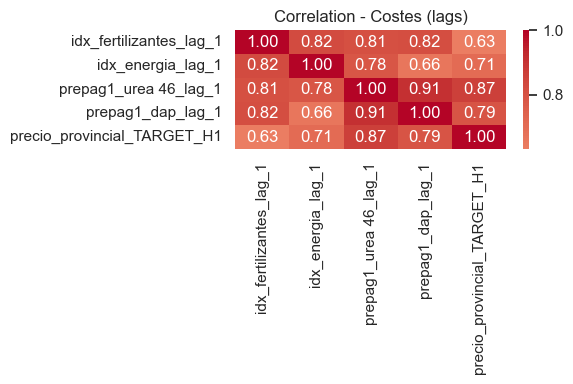


Block Demanda (lags) correlation with target:
precio_provincial_TARGET_H1       1.000000
prepag2_torta de girasol_lag_1    0.859020
idx_piensos_lag_1                 0.635649
prepag2_paja cereales_lag_1       0.235604
Name: precio_provincial_TARGET_H1, dtype: float64


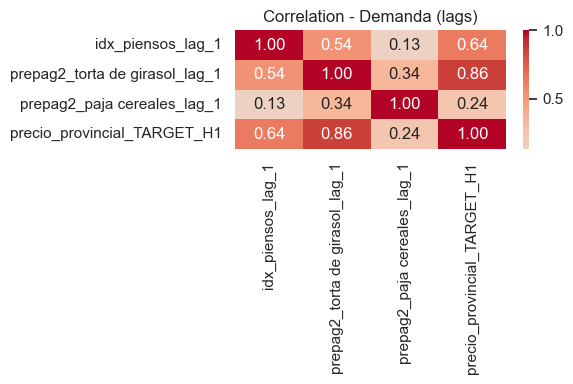


Block Internacional (lags) correlation with target:
precio_provincial_TARGET_H1    1.000000
wheat_intl_eur_lag_1           0.882645
wheat_intl_eur_lag_2           0.867650
corn_intl_eur_lag_1            0.842144
eur_usd_lag_1                 -0.363234
Name: precio_provincial_TARGET_H1, dtype: float64


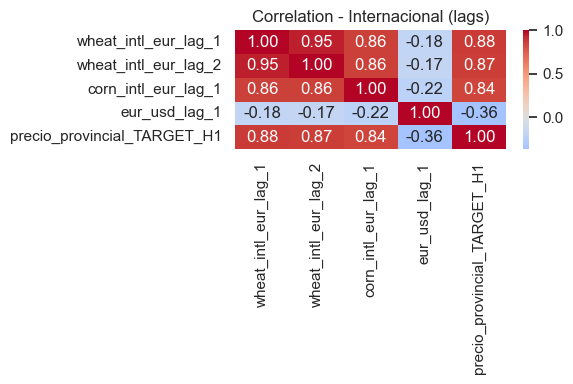

In [43]:
target_col = "precio_provincial_TARGET_H1"

blocks = {
    "Costes (lags)": [
        "idx_fertilizantes_lag_1",
        "idx_energia_lag_1",
        "prepag1_urea 46_lag_1",
        "prepag1_dap_lag_1",
    ],
    "Demanda (lags)": [
        "idx_piensos_lag_1",
        "prepag2_torta de girasol_lag_1",
        "prepag2_paja cereales_lag_1",
    ],
    "Internacional (lags)": [
        "wheat_intl_eur_lag_1",
        "wheat_intl_eur_lag_2",
        "corn_intl_eur_lag_1",
        "eur_usd_lag_1",
    ],
}

for block_name, candidates in blocks.items():
    cols = resolve_cols(df, candidates)
    if target_col in df.columns:
        cols = cols + [target_col]
    if len(cols) < 2:
        print(f"Block {block_name}: skipped (missing columns)")
        continue
    corr = df[cols].corr()
    print(f"\nBlock {block_name} correlation with target:")
    if target_col in corr.columns:
        print(corr[target_col].sort_values(ascending=False))
    plt.figure(figsize=(6, 4))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
    plt.title(f"Correlation - {block_name}")
    plt.tight_layout()
    plt.show()

### Interpretacion del bloque de correlaciones
- Si las variables internacionales (por ejemplo `wheat_intl_eur_lag_1`) muestran correlacion alta con el target, se confirma que la senal externa aporta poder explicativo real.
- Si costes (`idx_fertilizantes_lag_1`, `prepag1_urea 46_lag_1`, `prepag1_dap_lag_1`) mantienen correlacion positiva y estable, el modelo captura transmision de costes al precio.
- Si una familia cae cerca de 0 en todos los horizontes, debe revisarse su utilidad o su tratamiento temporal (lags, rolling o normalizacion).

## 3. Senal temporal (lead/lag)
Comparativa multiaxial con lags: `precio_provincial_lag_1` vs `idx_fertilizantes_lag_1` vs `wheat_intl_eur_lag_1`.

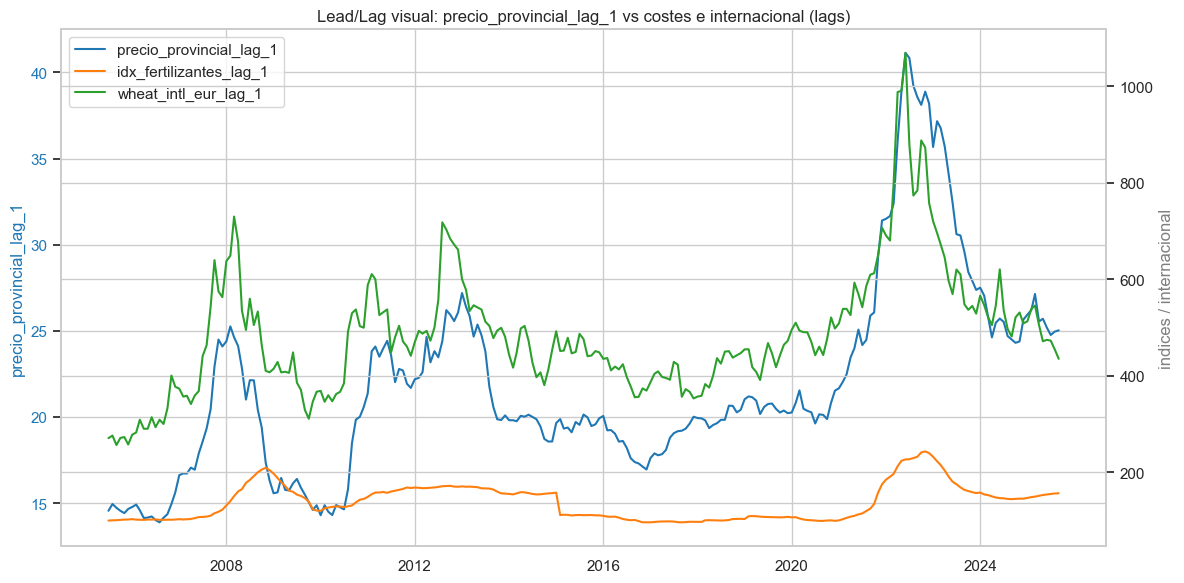

In [44]:
time_cols = [
    "precio_provincial_lag_1",
    "idx_fertilizantes_lag_1",
    "wheat_intl_eur_lag_1",
    "precio_provincial_TARGET_H1",
 ]
time_cols = resolve_cols(df, time_cols)
if "date" in df.columns and len(time_cols) >= 2:
    df_time = df.groupby("date", as_index=False)[time_cols].mean()
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(df_time["date"], df_time.get("precio_provincial_lag_1"), label="precio_provincial_lag_1", color="tab:blue")
    ax1.set_ylabel("precio_provincial_lag_1", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    if "idx_fertilizantes_lag_1" in df_time.columns:
        ax2.plot(df_time["date"], df_time["idx_fertilizantes_lag_1"], label="idx_fertilizantes_lag_1", color="tab:orange")
    if "wheat_intl_eur_lag_1" in df_time.columns:
        ax2.plot(df_time["date"], df_time["wheat_intl_eur_lag_1"], label="wheat_intl_eur_lag_1", color="tab:green")
    ax2.set_ylabel("indices / internacional", color="tab:gray")

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper left")
    plt.title("Lead/Lag visual: precio_provincial_lag_1 vs costes e internacional (lags)")
    plt.tight_layout()
    plt.show()
else:
    print("Missing date or required columns for temporal analysis.")

### Interpretacion de la senal temporal (lead/lag)
- Si precio, costes e internacional se mueven con desfase coherente, se justifica el uso de variables retardadas en lugar de contemporaneas.
- Si las series internacionales anticipan giros del precio provincial, se refuerza su papel como drivers tempranos.
- Si aparecen rupturas de relacion en 2022, el comportamiento es consistente con un escenario de shock y valida la necesidad de evaluacion out-of-time.

## 4. Componente espacial y logistica
Distancia a puerto vs precio (lag) y validacion de `precio_vecinos_media_lag1`.

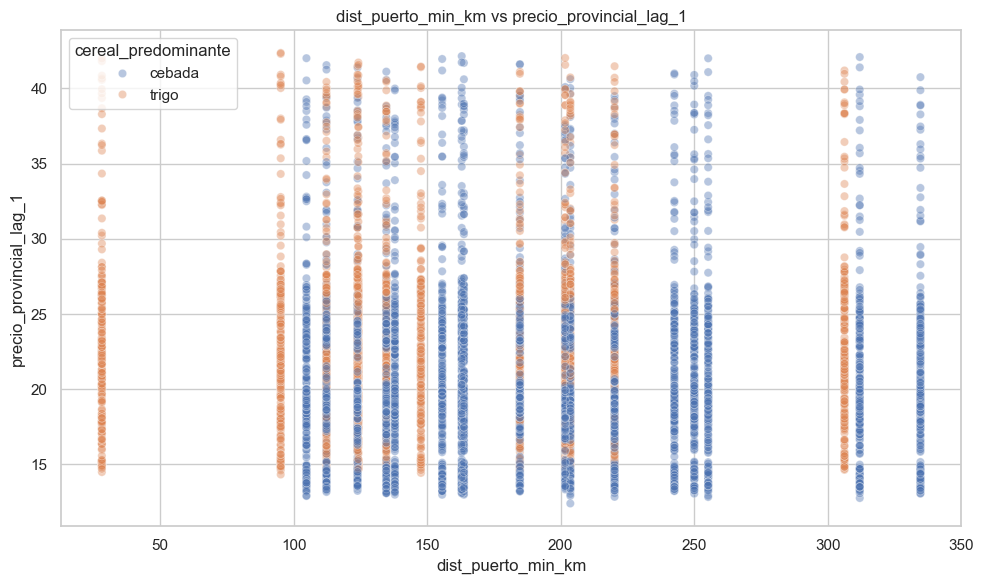

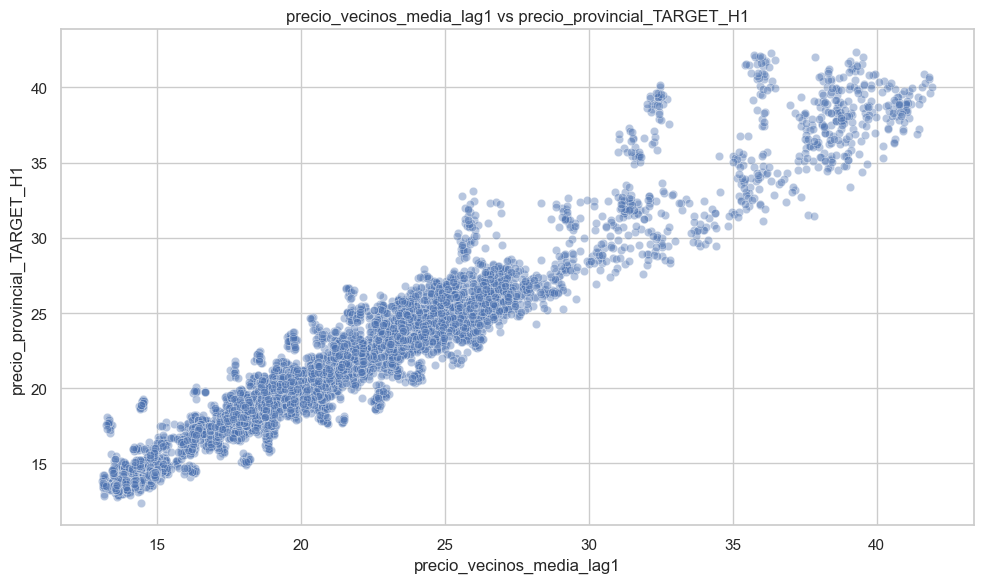

corr(precio_vecinos_media_lag1, precio_provincial_TARGET_H1): 0.9648097404575531


In [45]:
if all(col in df.columns for col in ["dist_puerto_min_km", "precio_provincial_lag_1", "cereal_predominante"]):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df,
        x="dist_puerto_min_km",
        y="precio_provincial_lag_1",
        hue="cereal_predominante",
        alpha=0.4,
    )
    plt.title("dist_puerto_min_km vs precio_provincial_lag_1")
    plt.tight_layout()
    plt.show()
else:
    print("Missing columns for distance vs price plot.")

if all(col in df.columns for col in ["precio_vecinos_media_lag1", "precio_provincial_TARGET_H1"]):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df,
        x="precio_vecinos_media_lag1",
        y="precio_provincial_TARGET_H1",
        alpha=0.4,
    )
    plt.title("precio_vecinos_media_lag1 vs precio_provincial_TARGET_H1")
    plt.tight_layout()
    plt.show()
    corr_val = df[["precio_vecinos_media_lag1", "precio_provincial_TARGET_H1"]].corr().iloc[0, 1]
    print("corr(precio_vecinos_media_lag1, precio_provincial_TARGET_H1):", corr_val)
else:
    print("Missing columns for neighbor price validation.")

### Interpretacion espacial y logistica
- Una relacion no lineal entre `dist_puerto_min_km` y precio es esperable: la logistica depende del cereal, region y rol importador/exportador.
- Si `precio_vecinos_media_lag1` concentra una correlacion muy alta con el target, confirma autocorrelacion espacial y riesgo de leakage.
- Este hallazgo respalda mantener esa variable fuera del set final de entrada cuando se aplica la Blacklist Nuclear.

## 5. Anomalias y clima
Distribucion de `z_clima_adverso` y `precip_relative_shock`, y validacion con picos de precio.

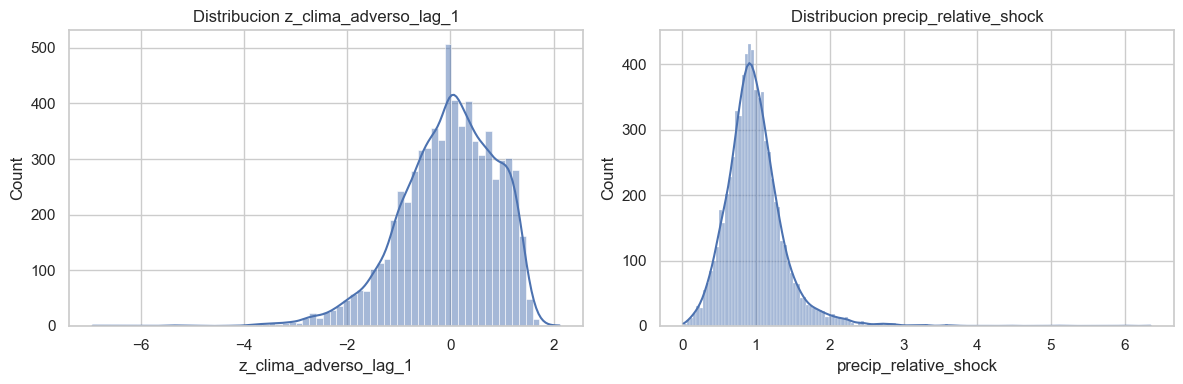

z_clima_adverso_lag_1 std: 0.9251242313975412
z_clima_adverso_lag_1 std > 0.5: OK


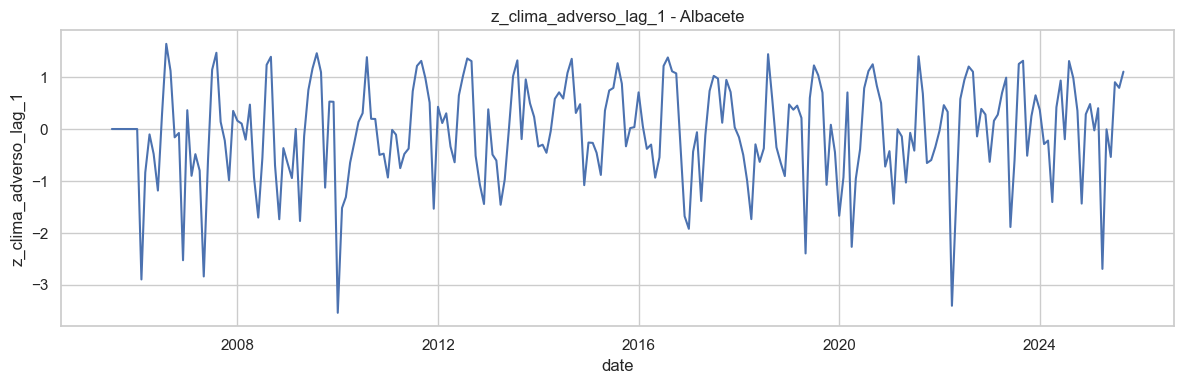

Outliers climaticos: 1277
         date    provincia cereal_predominante  z_clima_adverso_lag_1  \
5  2005-07-01        Cádiz               trigo               0.000000   
30 2005-08-01        Ávila              cebada               0.000000   
33 2005-08-01       Burgos               trigo               2.113820   
35 2005-08-01  Ciudad Real              cebada               0.000000   
37 2005-08-01       Cuenca              cebada               0.000000   
40 2005-08-01       Lleida              cebada               0.000000   
42 2005-08-01      Navarra               trigo               1.464017   
43 2005-08-01     Palencia              cebada               1.707522   
44 2005-08-01     Palencia               trigo               1.482570   
46 2005-08-01      Segovia              cebada               0.000000   

    precip_relative_shock  precio_provincial_TARGET_H1  
5                0.378356                    15.256366  
30               0.416966                    14.148300  

In [46]:
target_col = resolve_col(df, ["precio_provincial_TARGET_H1", "precio_provincial_TARGET"])
z_col = resolve_col(df, ["z_clima_adverso", "z_clima_adverso_lag_1", "z_clima_adverso_lag_2"])
shock_col = resolve_col(df, ["precip_relative_shock", "precip_relative_shock_lag_1"])
required_cols = ["date", "provincia"]

if target_col and z_col and shock_col and all(col in df.columns for col in required_cols):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[z_col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f"Distribucion {z_col}")
    sns.histplot(df[shock_col].dropna(), kde=True, ax=axes[1])
    axes[1].set_title(f"Distribucion {shock_col}")
    plt.tight_layout()
    plt.show()

    z_std = df[z_col].std()
    print(f"{z_col} std:", z_std)
    if z_std > 0.5:
        print(f"{z_col} std > 0.5: OK")
    else:
        print(f"{z_col} std <= 0.5: revisar senal")

    sample_prov = "Albacete"
    if sample_prov not in df["provincia"].unique():
        sample_prov = df["provincia"].iloc[0]
    df_prov = df[df["provincia"] == sample_prov].sort_values("date")
    plt.figure(figsize=(12, 4))
    plt.plot(df_prov["date"], df_prov[z_col], label=z_col)
    plt.title(f"{z_col} - {sample_prov}")
    plt.xlabel("date")
    plt.ylabel(z_col)
    plt.tight_layout()
    plt.show()

    outliers = df[
        (df[z_col].abs() >= 2)
        | (df[shock_col] >= 1.5)
        | (df[shock_col] <= 0.5)
    ]
    if outliers.empty:
        print("No outliers climaticos con umbrales actuales.")
    else:
        print("Outliers climaticos:", outliers.shape[0])
        print(outliers[["date", "provincia", "cereal_predominante", z_col, shock_col, target_col]].head(10))
        print(f"{target_col} mean (all):", df[target_col].mean())
        print(f"{target_col} mean (outliers):", outliers[target_col].mean())
else:
    missing = [col for col in required_cols if col not in df.columns]
    if not target_col:
        missing.append("precio_provincial_TARGET_H1|precio_provincial_TARGET")
    if not z_col:
        missing.append("z_clima_adverso|z_clima_adverso_lag_1|z_clima_adverso_lag_2")
    if not shock_col:
        missing.append("precip_relative_shock|precip_relative_shock_lag_1")
    print("Missing columns for climate anomaly analysis:", missing)

### Interpretacion de anomalias climaticas
- Si los outliers climaticos modifican la media del target frente al total, existe senal climatica util para decision.
- Si `z_clima_adverso` presenta dispersion suficiente (sin ser casi constante), la feature es informativa.
- Si no hay separacion entre outliers y no-outliers, conviene revisar umbrales o la forma de agregacion climatica.

## 6. Estacionalidad
Ciclicidad del precio usando agregaciones mensuales por cereal.

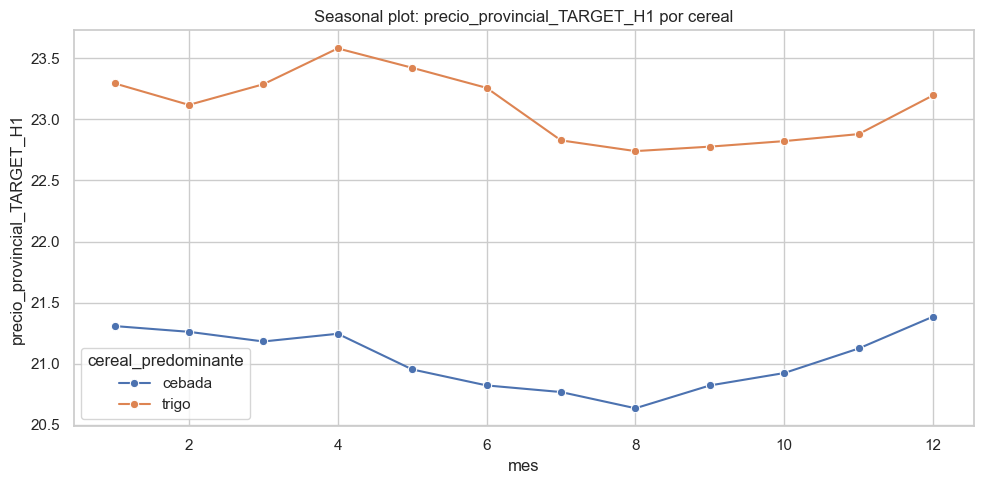

In [47]:
target_col = resolve_col(df, ["precio_provincial_TARGET_H1", "precio_provincial_TARGET"])
required_cols = ["date", "cereal_predominante"]

if target_col and all(col in df.columns for col in required_cols):
    df_season = df.copy()
    df_season["month"] = df_season["date"].dt.month
    season = (
        df_season.groupby(["month", "cereal_predominante"], as_index=False)
        [target_col]
        .mean()
    )
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=season, x="month", y=target_col, hue="cereal_predominante", marker="o")
    plt.title(f"Seasonal plot: {target_col} por cereal")
    plt.xlabel("mes")
    plt.ylabel(target_col)
    plt.tight_layout()
    plt.show()
else:
    missing = [col for col in required_cols if col not in df.columns]
    if not target_col:
        missing.append("precio_provincial_TARGET_H1|precio_provincial_TARGET")
    print("Missing columns for seasonality plot:", missing)

### Interpretacion de estacionalidad
- Si el patron mensual cambia por cereal, el comportamiento estacional esta presente y debe conservarse en features de calendario.
- Si hay meses con picos recurrentes, esos tramos son criticos para evaluar sesgo de sobre/infraestimacion.
- La consistencia entre ciclos estacionales y metricas por horizonte mejora la trazabilidad del modelo ante negocio.